# Portfolio optimization: Monte Carlo vs QAOA

### A €50,000 book of eight names — classical sampling versus a quantum QUBO

This notebook continues the paper-study series (`VaR`, credit risk, QML) and lands on
**portfolio construction**, the Level-2A theme of the thesis bibliography
(JPMorgan decomposition, BBVA/IBM VQE, PO-QA, annealing).

We take a concrete universe and a concrete budget:

| Ticker | Name | Venue |
|--------|------|-------|
| `RGTI` | Rigetti Computing | NASDAQ |
| `IONQ` | IonQ | NYSE |
| `QTMU.MI` → `QNTM.MI` | VanEck Quantum Computing UCITS ETF | Borsa Italiana |
| `RACE.MI` | Ferrari | Borsa Italiana |
| `LEGN` | Legend Biotech | NASDAQ |
| `TTWO` | Take-Two Interactive | NASDAQ |
| `LGND` | Ligand Pharmaceuticals | NASDAQ |
| `SMR` | NuScale Power | NYSE |

Yahoo Finance has **no** symbol `QTMU.MI`. The Milan quantum-computing ETF is
`QNTM.MI` (VanEck). The notebook tries the requested ticker first and falls back
automatically.

**Budget.** \(B = 50\,000\) EUR, long-only, no leverage.

**One-sentence preview**

> Classical Monte Carlo throws random weight vectors on the simplex and keeps the
> best Sharpe / min-vol points; the quantum route encodes a *discrete* Markowitz
> problem as a QUBO, maps it to an Ising Hamiltonian, and lets **QAOA** sample
> high-quality bitstrings. With eight assets the classical exact scan of \(2^8=256\)
> states is trivial — the point is the *method* and the scaling story, not a
> hardware speedup today.

**Roadmap**

1. Download (or synthesise) prices, convert everything to EUR
2. Estimate \(\mu\) and \(\Sigma\), look at the book
3. Classical Monte Carlo on the simplex + efficient-frontier sketch
4. Turn the max-Sharpe weights into an integer share ticket of €50k
5. QUBO / Ising encoding of a cardinality-constrained binary portfolio
6. Exact enumeration (ground truth) vs QAOA on Aer
7. Side-by-side allocation, risk, Sharpe, and runtime
8. Fair discrete twin (random Hamming-$K$ search) and out-of-sample ticket P&L
9. When a quantum algorithm *could* matter, and what this demo does not prove

> Related repo material: `../tesi/03_portfolio_optimization_qubo.py`,
> `../tesi/papers/L2A_portfolio/`.


## 0. Setup

`.venv-quantum`: `numpy`, `pandas`, `scipy`, `matplotlib`. `yfinance` is used when
the network is up; otherwise a reproducible synthetic book is generated so the
notebook still runs. Qiskit Aer is required only for the QAOA section — the
QUBO itself is enumerated with numpy.


In [1]:
import sys
from time import perf_counter

try:
    sys.stdout.reconfigure(encoding="utf-8")
except (AttributeError, ValueError):
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "font.size": 11,
    "axes.titlesize": 13,
})

rng = np.random.default_rng(42)

try:
    import qiskit  # noqa: F401
    import qiskit_aer  # noqa: F401
    HAS_QISKIT = True
except ImportError:
    HAS_QISKIT = False

print(f"numpy {np.__version__}  |  pandas {pd.__version__}  |  Qiskit available: {HAS_QISKIT}")


numpy 2.5.0  |  pandas 3.0.3  |  Qiskit available: True


## 1. Universe, budget, and data

Daily adjusted closes, about two years, converted to **EUR**. US names are
divided by `EURUSD=X`. Milan names (`.MI`) are already in euro.

Returns are simple daily returns; we annualise with \(252\) trading days:

$$
\mu \;=\; 252\,\mathbb{E}[r], \qquad
\Sigma \;=\; 252\,\mathrm{Cov}(r).
$$

That is the usual Markowitz input. It is **not** a forecast — it is a historical
plug-in, good enough to compare two *optimisers* on the same instance.


In [2]:
BUDGET_EUR = 50_000.0
RF_ANNUAL = 0.02          # euro cash proxy
LOOKBACK = "2y"
N_MC = 25_000
CARDINALITY_K = 4         # QUBO: pick K names, equal weight 1/K
RISK_AVERSION = 1.0       # lambda in  lambda * variance - return
QUBO_PENALTY = 8.0        # (sum x_i - K)^2
QAOA_P = 1                # QAOA depth (p=1 is enough to demo the hybrid loop)
QAOA_RESTARTS = 4
QAOA_MAXITER = 40

REQUESTED = ["RGTI", "IONQ", "QTMU.MI", "RACE.MI", "LEGN", "TTWO", "LGND", "SMR"]
FALLBACK_TICKER = {"QTMU.MI": "QNTM.MI"}
USD_VENUE = {"RGTI", "IONQ", "LEGN", "TTWO", "LGND", "SMR"}

NAMES = {
    "RGTI": "Rigetti Computing",
    "IONQ": "IonQ",
    "QTMU.MI": "VanEck Quantum Computing ETF (requested)",
    "QNTM.MI": "VanEck Quantum Computing UCITS ETF",
    "RACE.MI": "Ferrari",
    "LEGN": "Legend Biotech",
    "TTWO": "Take-Two Interactive",
    "LGND": "Ligand Pharmaceuticals",
    "SMR": "NuScale Power",
}


from pathlib import Path
from time import sleep

CACHE = Path("data") / "portfolio_prices_eur.csv"


def try_download(tickers: list[str], attempts: int = 2) -> pd.DataFrame | None:
    try:
        import yfinance as yf
    except ImportError:
        print("yfinance not installed — will use cache / synthetic prices.")
        return None
    last_err = None
    for k in range(attempts):
        try:
            raw = yf.download(
                tickers,
                period=LOOKBACK,
                auto_adjust=True,
                progress=False,
                threads=False,
            )
            if raw is None or raw.empty:
                last_err = "empty frame"
            else:
                close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
                if isinstance(close, pd.Series):
                    close = close.to_frame()
                close = close.dropna(axis=1, how="all")
                if close.shape[1] > 0:
                    return close
                last_err = "all columns empty"
        except Exception as exc:  # noqa: BLE001 — Yahoo is noisy
            last_err = exc
        print(f"  Yahoo attempt {k+1}/{attempts} failed ({last_err}); backing off.")
        sleep(4 * (k + 1))
    return None


def synthetic_book(tickers: list[str], n_days: int = 504) -> pd.DataFrame:
    '''GBM paths with a block-correlation structure (quantum / biotech / other).'''
    n = len(tickers)
    dates = pd.bdate_range("2024-08-01", periods=n_days)
    # annual vol / drift guesses — only used offline
    vol = np.array([0.90, 0.85, 0.35, 0.28, 0.55, 0.32, 0.40, 0.80][:n], dtype=float)
    mu_d = np.array([0.15, 0.18, 0.12, 0.10, 0.08, 0.11, 0.09, 0.05][:n]) / 252.0
    factor = rng.standard_normal((n_days, 3))
    loadings = np.array([
        [0.85, 0.10, 0.05],
        [0.80, 0.15, 0.05],
        [0.70, 0.10, 0.20],
        [0.10, 0.20, 0.70],
        [0.15, 0.80, 0.05],
        [0.10, 0.15, 0.75],
        [0.10, 0.75, 0.15],
        [0.25, 0.10, 0.65],
    ], dtype=float)[:n]
    idio = rng.standard_normal((n_days, n))
    z = 0.75 * factor @ loadings.T + 0.25 * idio
    z = (z - z.mean(0)) / z.std(0)
    log_r = mu_d + (vol / np.sqrt(252.0)) * z
    px0 = np.array([20.0, 40.0, 25.0, 350.0, 22.0, 240.0, 280.0, 10.0][:n])
    levels = px0 * np.exp(np.cumsum(log_r, axis=0))
    return pd.DataFrame(levels, index=dates, columns=tickers)


print("QTMU.MI is not a Yahoo symbol; requesting QNTM.MI (VanEck Quantum Computing UCITS ETF, Milan).")
yahoo_tickers = [FALLBACK_TICKER.get(t, t) for t in REQUESTED]
fx_close = None
px_raw = try_download(yahoo_tickers + ["EURUSD=X"])

tickers = list(yahoo_tickers)
used = [t for t in tickers if px_raw is not None and t in px_raw.columns and px_raw[t].notna().sum() > 40]
if px_raw is not None and "EURUSD=X" in px_raw.columns:
    fx_close = px_raw[["EURUSD=X"]]

if used and len(used) >= 6 and fx_close is not None and "EURUSD=X" in fx_close.columns:
    tickers = used
    px = px_raw[tickers].sort_index().ffill()
    usd = [t for t in tickers if t in USD_VENUE]
    eur_names = [t for t in tickers if t not in USD_VENUE]
    fx = fx_close["EURUSD=X"].reindex(px.index).ffill().bfill()
    usd_eur = px[usd].div(fx, axis=0) if usd else pd.DataFrame(index=px.index)
    px_eur = pd.concat([usd_eur, px[eur_names]], axis=1)[tickers].dropna(how="any")
    DATA_SOURCE = "yahoo"
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    px_eur.to_csv(CACHE)
    print(f"wrote cache {CACHE}")
elif CACHE.exists():
    print(f"Yahoo incomplete — loading cache {CACHE}")
    px_eur = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    tickers = list(px_eur.columns)
    DATA_SOURCE = "cache"
else:
    print("Yahoo incomplete and no cache — synthetic EUR prices.")
    tickers = list(yahoo_tickers)
    px_eur = synthetic_book(tickers)
    DATA_SOURCE = "synthetic"

labels = [f"{t}\n{NAMES.get(t, t)}" for t in tickers]
short = [NAMES.get(t, t).split("(")[0].strip() for t in tickers]
n_assets = len(tickers)
print(f"source = {DATA_SOURCE}  |  assets = {tickers}")
print(f"rows = {len(px_eur)}  |  {px_eur.index.min().date()} -> {px_eur.index.max().date()}")
print(px_eur.tail(3).round(3).to_string())


QTMU.MI is not a Yahoo symbol; requesting QNTM.MI (VanEck Quantum Computing UCITS ETF, Milan).


wrote cache data\portfolio_prices_eur.csv
source = yahoo  |  assets = ['RGTI', 'IONQ', 'QNTM.MI', 'RACE.MI', 'LEGN', 'TTWO', 'LGND', 'SMR']
rows = 303  |  2025-06-17 -> 2026-08-17
Ticker        RGTI    IONQ  QNTM.MI  RACE.MI    LEGN     TTWO     LGND    SMR
Date                                                                         
2026-08-13  16.149  39.011   26.245   355.25  17.580  209.809  250.494  8.543
2026-08-14  16.315  40.103   26.460   356.80  17.659  214.081  255.389  8.140
2026-08-17  16.225  39.881   26.460   356.80  17.561  212.896  253.975  8.095


## 2. Historical \(\mu\), \(\Sigma\), and a look at the book

Eight names, three stories sitting in the same ticket: **quantum hardware / ETF**,
**ex-growth biotech**, and **cash-flow businesses** (Ferrari, Take-Two) plus a
small-modular-reactor name. Correlation inside the quantum block is the first
thing an optimiser should notice — diversification is not “eight tickers”, it is
eight *independent* bets.


Annualised stats (historical plug-in)
 ticker                               name  last_EUR     mu   vol  Sharpe_rf
   RGTI                  Rigetti Computing    16.225  0.932 1.045      0.873
   IONQ                               IonQ    39.881  0.559 0.905      0.596
QNTM.MI VanEck Quantum Computing UCITS ETF    26.460  0.373 0.300      1.178
RACE.MI                            Ferrari   356.800 -0.030 0.344     -0.145
   LEGN                     Legend Biotech    17.561 -0.233 0.681     -0.371
   TTWO               Take-Two Interactive   212.896  0.076 0.306      0.182
   LGND             Ligand Pharmaceuticals   253.975  0.869 0.372      2.285
    SMR                      NuScale Power     8.095 -0.712 0.989     -0.740


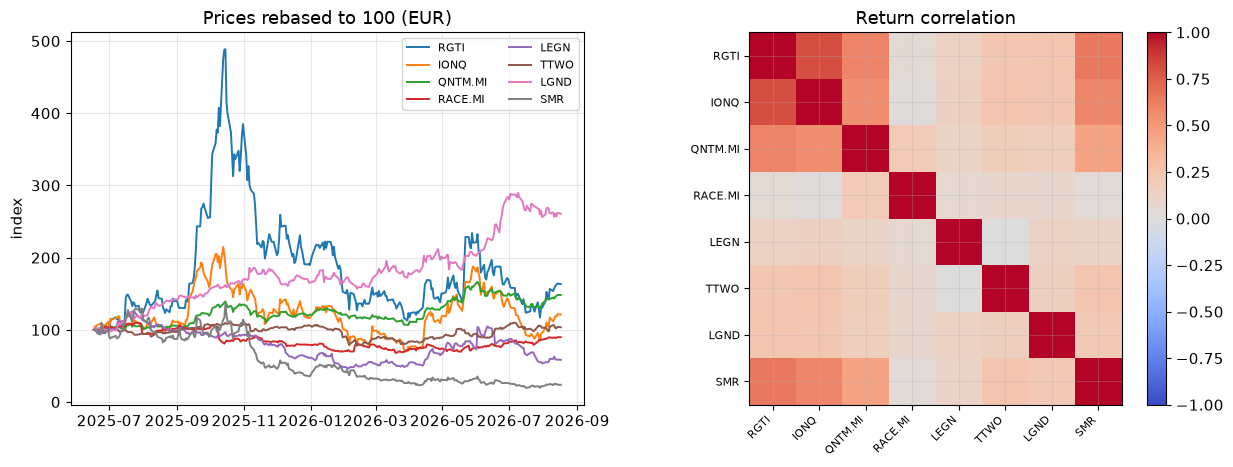

In [3]:
rets = px_eur.pct_change().dropna()
mu = rets.mean().to_numpy() * 252.0
cov = rets.cov().to_numpy() * 252.0
vol = np.sqrt(np.diag(cov))
corr = rets.corr().to_numpy()
last_px = px_eur.iloc[-1].to_numpy()

print("Annualised stats (historical plug-in)")
stats = pd.DataFrame({
    "ticker": tickers,
    "name": short,
    "last_EUR": last_px,
    "mu": mu,
    "vol": vol,
    "Sharpe_rf": (mu - RF_ANNUAL) / vol,
})
print(stats.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
normed = 100.0 * px_eur / px_eur.iloc[0]
for col in normed.columns:
    axes[0].plot(normed.index, normed[col], label=col, lw=1.4)
axes[0].set_title("Prices rebased to 100 (EUR)")
axes[0].set_ylabel("index")
axes[0].legend(fontsize=8, ncol=2)

im = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(n_assets), tickers, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(n_assets), tickers, fontsize=8)
axes[1].set_title("Return correlation")
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()


## 3. The Markowitz problem

Long-only fully invested weights \(w \in \mathbb{R}^n_{\ge 0}\), \(\mathbf{1}^\top w = 1\):

$$
\max_w \;\; \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}
\qquad\text{or equivalently}\qquad
\min_w \;\; \lambda\, w^\top \Sigma w \;-\; w^\top \mu.
$$

The **efficient frontier** is the set of portfolios that maximise expected return
for a given volatility. Monte Carlo does not *solve* the quadratic programme —
it **samples** the simplex (Dirichlet) and keeps the empirical envelope. That is
the textbook classical baseline used in bank decks when \(n\) is small and one
wants a picture, not a KKT certificate.

For \(n=8\) a QP solver would be faster and exact. We still use Monte Carlo
because that is the algorithm we are comparing against QAOA: both are
*stochastic search* procedures.


Monte Carlo: 25000 Dirichlet portfolios in 0.016 s
  max-Sharpe  ret=0.668  vol=0.288  Sh=2.254
  min-vol     ret=0.179  vol=0.205  Sh=0.774
  SLSQP QP    ret=0.708  vol=0.283  Sh=2.429


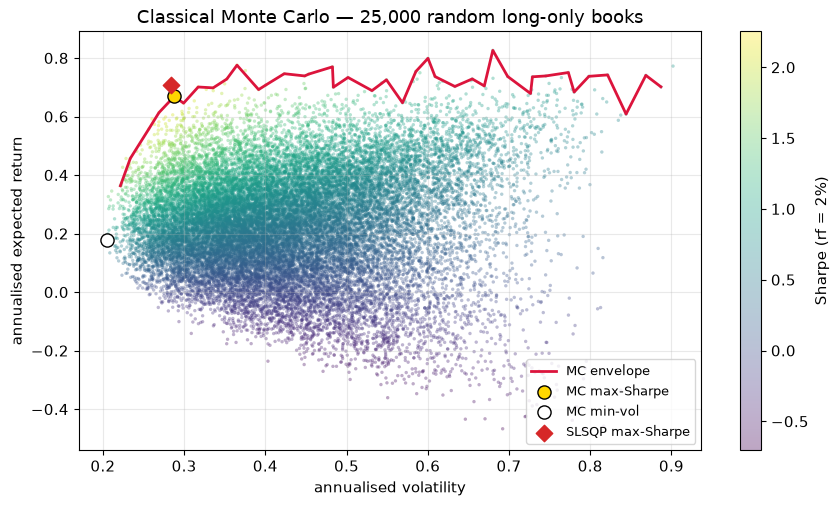

In [4]:
def port_ret(w: np.ndarray) -> float:
    return float(w @ mu)


def port_vol(w: np.ndarray) -> float:
    return float(np.sqrt(w @ cov @ w))


def port_sharpe(w: np.ndarray) -> float:
    v = port_vol(w)
    return (port_ret(w) - RF_ANNUAL) / v if v > 1e-12 else -np.inf


def markowitz_max_sharpe() -> np.ndarray:
    def neg_sharpe(w):
        w = np.clip(w, 0, None)
        s = w.sum()
        return -port_sharpe(w / s)

    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    bounds = [(0.0, 1.0)] * n_assets
    w0 = np.ones(n_assets) / n_assets
    res = minimize(neg_sharpe, w0, bounds=bounds, constraints=cons, method="SLSQP")
    w = np.clip(res.x, 0, None)
    return w / w.sum()


t0 = perf_counter()
W = rng.dirichlet(np.ones(n_assets), size=N_MC)
mc_ret = W @ mu
mc_vol = np.sqrt(np.einsum("ij,jk,ik->i", W, cov, W))
mc_sh = (mc_ret - RF_ANNUAL) / np.maximum(mc_vol, 1e-12)
i_sh = int(np.argmax(mc_sh))
i_vol = int(np.argmin(mc_vol))
w_mc_sharpe = W[i_sh]
w_mc_minvol = W[i_vol]
t_mc = perf_counter() - t0

w_qp = markowitz_max_sharpe()

# empirical frontier: max return in vol bins
order = np.argsort(mc_vol)
vol_sorted, ret_sorted = mc_vol[order], mc_ret[order]
n_bins = 40
edges = np.linspace(vol_sorted[0], vol_sorted[-1], n_bins + 1)
front_v, front_r = [], []
for b in range(n_bins):
    m = (vol_sorted >= edges[b]) & (vol_sorted < edges[b + 1])
    if m.any():
        j = np.argmax(ret_sorted[m])
        front_v.append(vol_sorted[m][j])
        front_r.append(ret_sorted[m][j])

print(f"Monte Carlo: {N_MC} Dirichlet portfolios in {t_mc:.3f} s")
print(f"  max-Sharpe  ret={port_ret(w_mc_sharpe):.3f}  vol={port_vol(w_mc_sharpe):.3f}  Sh={port_sharpe(w_mc_sharpe):.3f}")
print(f"  min-vol     ret={port_ret(w_mc_minvol):.3f}  vol={port_vol(w_mc_minvol):.3f}  Sh={port_sharpe(w_mc_minvol):.3f}")
print(f"  SLSQP QP    ret={port_ret(w_qp):.3f}  vol={port_vol(w_qp):.3f}  Sh={port_sharpe(w_qp):.3f}")

fig, ax = plt.subplots(figsize=(8.8, 5.2))
sc = ax.scatter(mc_vol, mc_ret, c=mc_sh, s=6, cmap="viridis", alpha=0.35, linewidths=0)
ax.plot(front_v, front_r, color="crimson", lw=2.0, label="MC envelope")
ax.scatter(port_vol(w_mc_sharpe), port_ret(w_mc_sharpe), s=90, c="gold", edgecolors="k", zorder=5, label="MC max-Sharpe")
ax.scatter(port_vol(w_mc_minvol), port_ret(w_mc_minvol), s=90, c="white", edgecolors="k", zorder=5, label="MC min-vol")
ax.scatter(port_vol(w_qp), port_ret(w_qp), s=70, marker="D", c="tab:red", zorder=5, label="SLSQP max-Sharpe")
fig.colorbar(sc, ax=ax, label="Sharpe (rf = 2%)")
ax.set_xlabel("annualised volatility")
ax.set_ylabel("annualised expected return")
ax.set_title(f"Classical Monte Carlo — {N_MC:,} random long-only books")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


## 4. From weights to a €50,000 ticket

Continuous weights are not a trade. We convert \(w\) into **integer shares**
with a greedy leftover pass: floor each target notional, then spend residual
cash on the cheapest names that still fit. Leftover cash stays in EUR.


In [5]:
def shares_from_weights(w: np.ndarray, prices: np.ndarray, budget: float) -> tuple[np.ndarray, float]:
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 0, None)
    if w.sum() <= 0:
        return np.zeros(len(w), dtype=int), budget
    w = w / w.sum()
    shares = np.floor(w * budget / prices).astype(int)
    leftover = budget - float(shares @ prices)
    eligible = np.where(w > 1e-8)[0]
    if len(eligible):
        cheap = eligible[np.argsort(prices[eligible])]
        grew = True
        while grew:
            grew = False
            for i in cheap:
                if prices[i] <= leftover + 1e-9:
                    shares[i] += 1
                    leftover -= float(prices[i])
                    grew = True
    return shares, leftover


def ticket_table(tag: str, w: np.ndarray) -> pd.DataFrame:
    shares, cash = shares_from_weights(w, last_px, BUDGET_EUR)
    notional = shares * last_px
    invested = float(notional.sum())
    w_real = notional / BUDGET_EUR
    df = pd.DataFrame({
        "ticker": tickers,
        "name": short,
        "px_EUR": last_px,
        "weight_opt": w / w.sum(),
        "shares": shares,
        "notional_EUR": notional,
        "weight_book": w_real,
    })
    print(f"\n=== {tag} ===")
    print(df.round(3).to_string(index=False))
    print(f"invested {invested:,.2f} EUR | leftover cash {cash:,.2f} EUR | "
          f"E[r]={port_ret(w_real):.3f}  vol={port_vol(w_real):.3f}  Sh={port_sharpe(w_real):.3f}")
    return df


ticket_mc = ticket_table("Monte Carlo max-Sharpe", w_mc_sharpe)
ticket_qp = ticket_table("SLSQP max-Sharpe (classical QP, for reference)", w_qp)



=== Monte Carlo max-Sharpe ===
 ticker                               name  px_EUR  weight_opt  shares  notional_EUR  weight_book
   RGTI                  Rigetti Computing  16.225       0.057     179      2904.225        0.058
   IONQ                               IonQ  39.881       0.008      11       438.688        0.009
QNTM.MI VanEck Quantum Computing UCITS ETF  26.460       0.250     475     12568.500        0.251
RACE.MI                            Ferrari 356.800       0.044       6      2140.800        0.043
   LEGN                     Legend Biotech  17.561       0.033      96      1685.854        0.034
   TTWO               Take-Two Interactive 212.896       0.003       0         0.000        0.000
   LGND             Ligand Pharmaceuticals 253.975       0.605     119     30222.985        0.604
    SMR                      NuScale Power   8.095       0.000       4        32.380        0.001
invested 49,993.43 EUR | leftover cash 6.57 EUR | E[r]=0.669  vol=0.289  Sh=2.247

===

## 5. Discrete Markowitz as a QUBO (the quantum-friendly form)

QAOA and quantum annealers do not eat continuous \(w\). They eat **binary**
variables. Standard encoding in the L2A papers:

$$
x_i \in \{0,1\}, \qquad
w \;=\; \frac{x}{K}, \qquad
\sum_{i=1}^{n} x_i \;=\; K.
$$

Pick \(K\) names, hold them **equal-weight**. The mean-variance cost plus a
quadratic cardinality penalty is already a QUBO:

$$
H(x)
\;=\;
\lambda \left(\frac{x}{K}\right)^\top \Sigma \left(\frac{x}{K}\right)
\;-\;
\mu^\top \left(\frac{x}{K}\right)
\;+\;
P \left(\mathbf{1}^\top x - K\right)^2.
$$

Expanding, \(H(x) = x^\top Q x + \text{const}\) with a symmetric \(Q\). Map to
Ising with \(x_i = (1-Z_i)/2\); the cost Hamiltonian is a 2-local Pauli-\(Z\)
operator — exactly what **QAOA** wants.

With \(n=8\), \(2^n = 256\). We **enumerate** every bitstring (classical ground
truth) and only then ask QAOA to rediscover the optimum. That is the honest
NISQ demo: same instance, two search procedures.


In [6]:
def qubo_matrix(mu_vec, cov_mat, k, lam, penalty):
    '''Return symmetric Q such that H(x) = x^T Q x + const, dropping the pure constant.'''
    n = len(mu_vec)
    invk = 1.0 / k
    # lambda (x/K)^T Sigma (x/K) - mu^T (x/K) + P (1^T x - K)^2
    q = lam * (invk ** 2) * cov_mat - np.diag(invk * mu_vec)
    # P (sum x_i)^2 - 2 P K sum x_i   (K^2 P is a constant)
    q = q + penalty * np.ones((n, n))
    q = q - np.diag(np.full(n, 2.0 * penalty * k))
    return 0.5 * (q + q.T)


def bits_of(idx: int, n: int) -> np.ndarray:
    return np.array([(idx >> i) & 1 for i in range(n)], dtype=float)


def energy_qubo(x: np.ndarray, Q: np.ndarray) -> float:
    return float(x @ Q @ x)


Q = qubo_matrix(mu, cov, CARDINALITY_K, RISK_AVERSION, QUBO_PENALTY)

t0 = perf_counter()
n_space = 1 << n_assets
energies = np.empty(n_space)
xs = np.empty((n_space, n_assets))
for idx in range(n_space):
    x = bits_of(idx, n_assets)
    xs[idx] = x
    energies[idx] = energy_qubo(x, Q)
t_exact = perf_counter() - t0

best_idx = int(np.argmin(energies))
x_exact = xs[best_idx]
w_exact = x_exact / max(x_exact.sum(), 1.0)

print(f"QUBO enumerated {n_space} bitstrings in {t_exact*1e3:.2f} ms")
print(f"  min H = {energies[best_idx]:.6f}  |  Hamming weight = {int(x_exact.sum())} (target K={CARDINALITY_K})")
print("  selected:", [t for t, b in zip(tickers, x_exact) if b > 0.5])
print(f"  equal-weight book: ret={port_ret(w_exact):.3f}  vol={port_vol(w_exact):.3f}  Sh={port_sharpe(w_exact):.3f}")

# also score every feasible (Hamming = K) by Sharpe, for a finance-side check
feas = xs.sum(1) == CARDINALITY_K
w_feas = xs[feas] / CARDINALITY_K
sh_feas = np.array([port_sharpe(w) for w in w_feas])
x_best_sh = xs[feas][int(np.argmax(sh_feas))]
print("  best Sharpe among Hamming-K books:",
      [t for t, b in zip(tickers, x_best_sh) if b > 0.5],
      f"Sh={sh_feas.max():.3f}")


QUBO enumerated 256 bitstrings in 5.25 ms
  min H = -128.424452  |  Hamming weight = 4 (target K=4)
  selected: ['RGTI', 'QNTM.MI', 'TTWO', 'LGND']
  equal-weight book: ret=0.563  vol=0.372  Sh=1.460
  best Sharpe among Hamming-K books: ['QNTM.MI', 'RACE.MI', 'TTWO', 'LGND'] Sh=1.532


## 6. QAOA — the quantum search

Farhi, Goldstone & Gutmann (2014). Depth \(p\), cost unitary \(e^{-i\gamma H_C}\),
mixer \(e^{-i\beta H_M}\) with \(H_M = \sum_i X_i\), start from \(|+\rangle^{\otimes n}\):

$$
|\psi(\beta,\gamma)\rangle
\;=\;
\Biggl(\prod_{k=1}^{p} e^{-i\beta_k H_M}\, e^{-i\gamma_k H_C}\Biggr) |+\rangle^{\otimes n}.
$$

A **classical** optimiser (COBYLA) tunes \((\beta,\gamma)\) to minimise
\(\langle H_C \rangle\). Then we sample the prepared state. That hybrid loop is
what “a quantum portfolio algorithm” means on NISQ hardware.

Implementation notes:

- \(H_C\) is the Ising image of \(Q\), as a `SparsePauliOp`
- circuit: Qiskit `QAOAAnsatz`, \(p=1\) (2 variational angles — enough to see the hybrid loop)
- expectation: exact statevector on Aer (8 qubits \(\Rightarrow\) 256 amplitudes); we evaluate \(\langle H_{\mathrm{QUBO}}\rangle\) from the amplitudes, which is \(\langle H_C\rangle\) up to a constant
- several random restarts, keep the lowest energy
- final ticket: **1024 shots**, keep the lowest-energy Hamming-\(K\) sample
  (the usual QAOA post-process — not “take the mode”)


In [7]:
def qubo_to_ising(Q: np.ndarray):
    '''x^T Q x  with x=(1-Z)/2  ->  SparsePauliOp + offset.'''
    from qiskit.quantum_info import SparsePauliOp

    n = Q.shape[0]
    Qs = 0.5 * (Q + Q.T)
    offset = 0.0
    z = np.zeros(n)
    zz = {}
    for i in range(n):
        offset += 0.5 * Qs[i, i]
        z[i] += -0.5 * Qs[i, i]
        for j in range(i + 1, n):
            # 2 Q_ij x_i x_j = (Q_ij / 2) * (1 - Z_i - Z_j + Z_i Z_j)
            qij = Qs[i, j]
            offset += 0.5 * qij
            z[i] += -0.5 * qij
            z[j] += -0.5 * qij
            zz[(i, j)] = zz.get((i, j), 0.0) + 0.5 * qij

    labels, coeffs = [], []
    for i, c in enumerate(z):
        if abs(c) < 1e-14:
            continue
        s = ["I"] * n
        s[n - 1 - i] = "Z"
        labels.append("".join(s))
        coeffs.append(c)
    for (i, j), c in zz.items():
        if abs(c) < 1e-14:
            continue
        s = ["I"] * n
        s[n - 1 - i] = "Z"
        s[n - 1 - j] = "Z"
        labels.append("".join(s))
        coeffs.append(c)
    op = SparsePauliOp.from_list(list(zip(labels, coeffs))) if labels else SparsePauliOp("I" * n, 0.0)
    return op, offset


def decode_bitstring(bits: str) -> np.ndarray:
    '''Qiskit little-endian: rightmost char is qubit 0 = asset 0.'''
    rev = bits[::-1]
    return np.array([int(c) for c in rev[:n_assets]], dtype=float)


x_qaoa = None
w_qaoa = None
t_qaoa = np.nan
qaoa_history = []
qaoa_counts = {}
qaoa_shots = np.array([], dtype=int)
qaoa_probs = None
ising_offset = 0.0
prob_opt = np.nan

if not HAS_QISKIT:
    print("Qiskit not available — skip QAOA and use the exact QUBO bitstring.")
    x_qaoa, w_qaoa = x_exact.copy(), w_exact.copy()
else:
    from qiskit.circuit.library import QAOAAnsatz
    from qiskit.quantum_info import Statevector

    cost_op, ising_offset = qubo_to_ising(Q)
    ansatz = QAOAAnsatz(cost_op, reps=QAOA_P).decompose(reps=3)
    npar = ansatz.num_parameters
    print(f"QAOA ansatz: {ansatz.num_qubits} qubits, p={QAOA_P}, {npar} parameters")
    print(f"Ising offset (constant) = {ising_offset:.6f}")
    print(f"  depth={ansatz.depth()}  ops={dict(ansatz.count_ops())}")

    def energy_from_params(theta):
        bound = ansatz.assign_parameters(theta, inplace=False)
        sv = Statevector.from_instruction(bound)
        probs = np.abs(np.asarray(sv.data)) ** 2
        return float(probs @ energies)

    t0 = perf_counter()
    best_fun, best_theta = np.inf, None
    for r in range(QAOA_RESTARTS):
        hist = []
        theta0 = rng.uniform(0.0, np.pi, size=npar)

        def wrapped(th, _hist=hist):
            val = energy_from_params(th)
            _hist.append(val)
            return val

        res = minimize(wrapped, theta0, method="COBYLA", options={"maxiter": QAOA_MAXITER, "rhobeg": 0.5})
        qaoa_history.append(hist)
        if res.fun < best_fun:
            best_fun, best_theta = float(res.fun), np.asarray(res.x, dtype=float)
        print(f"  restart {r+1}/{QAOA_RESTARTS}: <H_QUBO>={res.fun:.6f}  nfev={res.nfev}")

    bound = ansatz.assign_parameters(best_theta)
    sv = Statevector.from_instruction(bound)
    probs = np.abs(sv.data) ** 2
    # index i: little-endian bits of i are the computational basis
    top = np.argsort(probs)[::-1]
    print("\nTop sampled computational-basis states:")
    for k in top[:8]:
        x = bits_of(int(k), n_assets)
        print(f"  P={probs[k]:.4f}  x={x.astype(int)}  H={energies[k]:.4f}  |x|={int(x.sum())}")

    # Hardware-like readout: 1024 shots, keep the lowest-energy Hamming-K sample.
    n_shots = 1024
    shots = rng.choice(n_space, size=n_shots, p=probs)
    qaoa_shots = shots.copy()
    qaoa_probs = probs.copy()
    seen = np.unique(shots)
    feas = seen[xs[seen].sum(1) == CARDINALITY_K]
    if len(feas):
        pick = int(feas[np.argmin(energies[feas])])
        chosen = xs[pick].copy()
        prob_opt = float(probs[pick])
        print(f"best Hamming-K among {n_shots} shots: H={energies[pick]:.6f}  "
              f"P={prob_opt:.4f}  unique={len(seen)}  (exact min {energies[best_idx]:.6f})")
    else:
        chosen = bits_of(int(top[0]), n_assets)
        k_now = int(chosen.sum())
        if k_now > CARDINALITY_K:
            on = np.where(chosen > 0.5)[0]
            drop = on[np.argsort(mu[on])[: k_now - CARDINALITY_K]]
            chosen[drop] = 0
        elif k_now < CARDINALITY_K:
            off = np.where(chosen < 0.5)[0]
            add = off[np.argsort(-mu[off])[: CARDINALITY_K - k_now]]
            chosen[add] = 1
        print("no Hamming-K mass in the head of the distribution — snapped to K.")

    x_qaoa = chosen
    w_qaoa = x_qaoa / max(x_qaoa.sum(), 1.0)
    t_qaoa = perf_counter() - t0
    qaoa_counts = {int(k): float(probs[k]) for k in top[:32]}
    print(f"\nQAOA wall time {t_qaoa:.2f} s")
    print("  selected:", [t for t, b in zip(tickers, x_qaoa) if b > 0.5])
    print(f"  H(x)={energy_qubo(x_qaoa, Q):.6f}  vs exact min {energies[best_idx]:.6f}")
    print(f"  equal-weight book: ret={port_ret(w_qaoa):.3f}  vol={port_vol(w_qaoa):.3f}  Sh={port_sharpe(w_qaoa):.3f}")
    match = np.allclose(x_qaoa, x_exact)
    print(f"  recovered exact QUBO optimum: {match}")


QAOA ansatz: 8 qubits, p=1, 2 parameters
Ising offset (constant) = -112.007173
  depth=42  ops={'cx': 56, 'rz': 28, 'u': 8, 'p': 8, 'r': 8}


  restart 1/4: <H_QUBO>=-112.573571  nfev=40


  restart 2/4: <H_QUBO>=-124.158631  nfev=40


  restart 3/4: <H_QUBO>=-124.315115  nfev=40


  restart 4/4: <H_QUBO>=-124.236103  nfev=40

Top sampled computational-basis states:
  P=0.0168  x=[1 0 1 0 0 1 1 0]  H=-128.4245  |x|=4
  P=0.0161  x=[1 0 1 1 0 0 1 0]  H=-128.4036  |x|=4
  P=0.0150  x=[0 1 1 0 0 1 1 0]  H=-128.3556  |x|=4
  P=0.0144  x=[1 1 1 0 0 0 1 0]  H=-128.3892  |x|=4
  P=0.0144  x=[0 1 1 1 0 0 1 0]  H=-128.3359  |x|=4
  P=0.0143  x=[1 0 0 1 0 1 1 0]  H=-128.3449  |x|=4
  P=0.0135  x=[1 0 1 0 1 0 1 0]  H=-128.3187  |x|=4
  P=0.0133  x=[1 1 0 0 0 1 1 0]  H=-128.3394  |x|=4
best Hamming-K among 1024 shots: H=-128.424452  P=0.0168  unique=186  (exact min -128.424452)

QAOA wall time 2.48 s
  selected: ['RGTI', 'QNTM.MI', 'TTWO', 'LGND']
  H(x)=-128.424452  vs exact min -128.424452
  equal-weight book: ret=0.563  vol=0.372  Sh=1.460
  recovered exact QUBO optimum: True


fraction of shots with Hamming weight K=4: 61.9%
P(ground state) under the prepared wavefunction: 0.0168


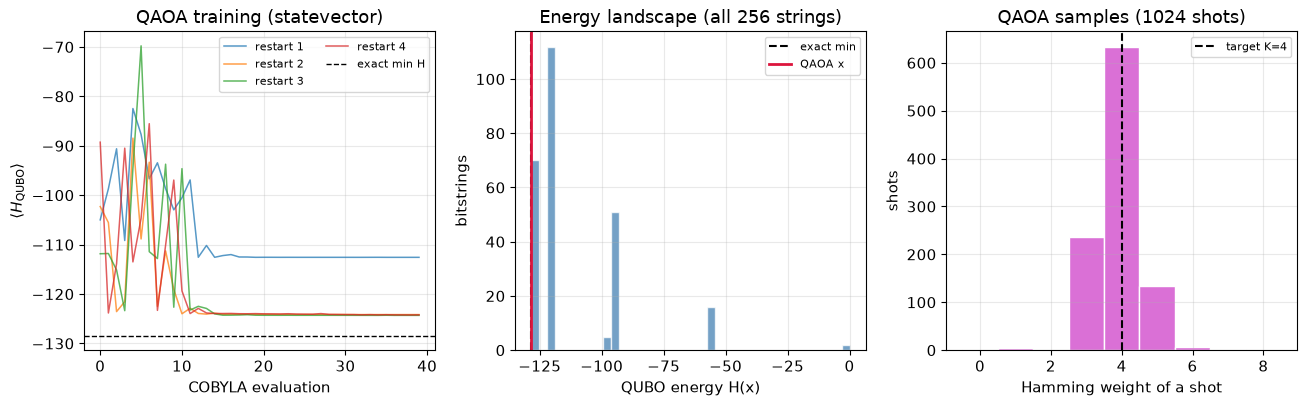

QAOA circuit after decompose: depth=42  gates={'cx': 56, 'p': 28, 'u': 24}
(full 8-qubit diagram omitted — all-to-all ZZ is unreadable in text)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))

if qaoa_history:
    for i, hist in enumerate(qaoa_history):
        axes[0].plot(hist, lw=1.1, alpha=0.75, label=f"restart {i+1}")
    axes[0].axhline(energies[best_idx], color="k", ls="--", lw=1, label="exact min H")
    axes[0].set_xlabel("COBYLA evaluation")
    axes[0].set_ylabel(r"$\langle H_{\mathrm{QUBO}}\rangle$")
    axes[0].set_title("QAOA training (statevector)")
    axes[0].legend(fontsize=8, ncol=2)
else:
    axes[0].text(0.5, 0.5, "QAOA not run", ha="center", va="center")
    axes[0].set_axis_off()

axes[1].hist(energies, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
axes[1].axvline(energies[best_idx], color="k", ls="--", label="exact min")
axes[1].axvline(energy_qubo(x_qaoa, Q), color="crimson", lw=2, label="QAOA x")
axes[1].set_xlabel("QUBO energy H(x)")
axes[1].set_ylabel("bitstrings")
axes[1].set_title("Energy landscape (all 256 strings)")
axes[1].legend(fontsize=8)

if len(qaoa_shots):
    hw = xs[qaoa_shots].sum(1)
    axes[2].hist(hw, bins=np.arange(-0.5, n_assets + 1.5, 1.0), color="orchid",
                 edgecolor="white", align="mid")
    axes[2].axvline(CARDINALITY_K, color="k", ls="--", label=f"target K={CARDINALITY_K}")
    axes[2].set_xlabel("Hamming weight of a shot")
    axes[2].set_ylabel("shots")
    axes[2].set_title(f"QAOA samples ({len(qaoa_shots)} shots)")
    axes[2].legend(fontsize=8)
    frac_k = float((hw == CARDINALITY_K).mean())
    print(f"fraction of shots with Hamming weight K={CARDINALITY_K}: {frac_k:.1%}")
    print(f"P(ground state) under the prepared wavefunction: {float(qaoa_probs[best_idx]):.4f}")
else:
    axes[2].text(0.5, 0.5, "no shots", ha="center", va="center")
    axes[2].set_axis_off()

fig.tight_layout()
plt.show()

if HAS_QISKIT:
    deco = ansatz.decompose()
    print(f"QAOA circuit after decompose: depth={deco.depth()}  gates={dict(deco.count_ops())}")
    print("(full 8-qubit diagram omitted — all-to-all ZZ is unreadable in text)")


## 7. Same €50k, two algorithms — the comparison

Monte Carlo returns a **dense** long-only vector (any name can get 3%). QAOA
returns a **cardinality-\(K\)** equal-weight subset. They are not solving the
identical programme; they are two encodings of “build me a book”. The fair
questions are:

1. Did QAOA find the QUBO ground state that brute force already knows?
2. How does that discrete book compare, in Sharpe / vol / names, with the MC
   max-Sharpe ticket after both are turned into integer shares?
3. What did each method *cost* in wall time on a laptop?

The next section makes the comparison *fairer*: same discrete space, then an out-of-sample P&L of the frozen €50k tickets.



=== QAOA equal-weight (K=4) ===
 ticker                               name  px_EUR  weight_opt  shares  notional_EUR  weight_book
   RGTI                  Rigetti Computing  16.225        0.25     775     12574.159        0.251
   IONQ                               IonQ  39.881        0.00       0         0.000        0.000
QNTM.MI VanEck Quantum Computing UCITS ETF  26.460        0.25     477     12621.420        0.252
RACE.MI                            Ferrari 356.800        0.00       0         0.000        0.000
   LEGN                     Legend Biotech  17.561        0.00       0         0.000        0.000
   TTWO               Take-Two Interactive 212.896        0.25      58     12347.944        0.247
   LGND             Ligand Pharmaceuticals 253.975        0.25      49     12444.759        0.249
    SMR                      NuScale Power   8.095        0.00       0         0.000        0.000
invested 49,988.28 EUR | leftover cash 11.72 EUR | E[r]=0.564  vol=0.373  Sh=1.458

=

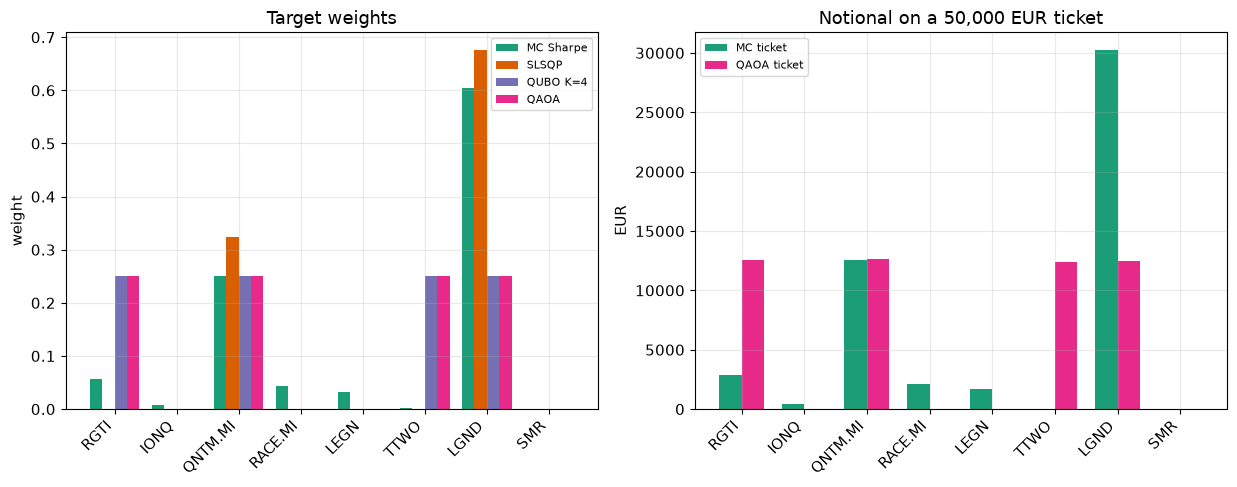

In [9]:
ticket_qaoa = ticket_table(f"QAOA equal-weight (K={CARDINALITY_K})", w_qaoa)
ticket_exact = ticket_table(f"Exact QUBO equal-weight (K={CARDINALITY_K})", w_exact)

rows = []
for tag, w, tsec in [
    ("MC max-Sharpe", w_mc_sharpe, t_mc),
    ("SLSQP max-Sharpe", w_qp, np.nan),
    ("Exact QUBO (K-subset)", w_exact, t_exact),
    ("QAOA (K-subset)", w_qaoa, t_qaoa),
]:
    sh, cash = shares_from_weights(w, last_px, BUDGET_EUR)
    wr = (sh * last_px) / BUDGET_EUR
    rows.append({
        "method": tag,
        "E[r]": port_ret(wr),
        "vol": port_vol(wr),
        "Sharpe": port_sharpe(wr),
        "names_held": int((sh > 0).sum()),
        "invested_EUR": float(sh @ last_px),
        "cash_EUR": cash,
        "wall_s": tsec,
    })
cmp = pd.DataFrame(rows)
print("\n=== €50,000 books after integer lots ===")
print(cmp.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
x = np.arange(n_assets)
w_plot = np.vstack([
    w_mc_sharpe / w_mc_sharpe.sum(),
    w_qp / w_qp.sum(),
    w_exact,
    w_qaoa,
])
width = 0.2
for i, (lab, col) in enumerate(zip(
    ["MC Sharpe", "SLSQP", f"QUBO K={CARDINALITY_K}", "QAOA"],
    ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"],
)):
    axes[0].bar(x + (i - 1.5) * width, w_plot[i], width, label=lab, color=col)
axes[0].set_xticks(x, tickers, rotation=45, ha="right")
axes[0].set_ylabel("weight")
axes[0].set_title("Target weights")
axes[0].legend(fontsize=8)

notionals = []
for w in (w_mc_sharpe, w_qaoa):
    sh, _ = shares_from_weights(w, last_px, BUDGET_EUR)
    notionals.append(sh * last_px)
axes[1].bar(x - 0.18, notionals[0], 0.36, label="MC ticket", color="#1b9e77")
axes[1].bar(x + 0.18, notionals[1], 0.36, label="QAOA ticket", color="#e7298a")
axes[1].set_xticks(x, tickers, rotation=45, ha="right")
axes[1].set_ylabel("EUR")
axes[1].set_title(f"Notional on a {BUDGET_EUR:,.0f} EUR ticket")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 8. Fair discrete twin, and what the tickets actually did

Two gaps in section 7.

**Search space.** Monte Carlo walks the *simplex*; QAOA walks *bitstrings*. A fairer classical twin is random search over the same Hamming-\(K\) subsets (\(\binom{8}{4}=70\)). Plot the running-best QUBO energy versus number of evaluations: if QAOA is doing anything useful, its cumulative best should drop faster than uniform sampling of feasible books.

**Look-ahead.** \(\mu\) and \(\Sigma\) were estimated on the *whole* sample, then turned into a ticket. That is in-sample optimisation, not a test. Split the return history 70/30: rebuild \(\mu,\Sigma\) on the first window, freeze both tickets at the split date, and read P&L on the held-out window. Still a toy (one split, no costs, no rebalance) — but it answers “would this €50k book have survived the next months?” instead of only quoting plug-in Sharpe.


feasible Hamming-K books: 70  (C(8,4))
train 2025-06-18 -> 2026-04-10  (211 days)
test  2026-04-13 -> 2026-08-17  (91 days)
OOS frozen tickets (shares bought at the split close):
                                 end_EUR    P&L_EUR  ann_ret  ann_vol  Sharpe  max_DD
MC / SLSQP (train weights)     71577.936  21577.936    1.073    0.397   2.651  -0.120
QUBO K-subset (train weights)  66155.559  16155.559    0.859    0.411   2.043  -0.142
MC names: ['RGTI', 'QNTM.MI', 'LGND']
QUBO names: ['RGTI', 'QNTM.MI', 'TTWO', 'LGND']


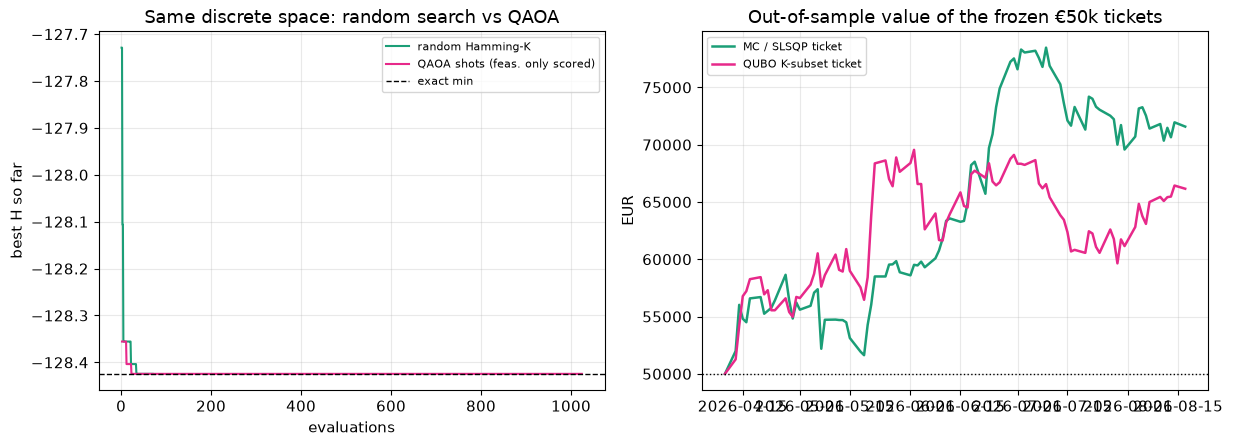

In [10]:
# --- 8a. running-best energy: random Hamming-K vs QAOA shots ---
feas_idx = np.where(xs.sum(1) == CARDINALITY_K)[0]
print(f"feasible Hamming-K books: {len(feas_idx)}  (C({n_assets},{CARDINALITY_K}))")

rand_order = rng.permutation(feas_idx)
rand_best = np.minimum.accumulate(energies[rand_order])

qaoa_run = []
best_so_far = np.inf
if len(qaoa_shots):
    for s in qaoa_shots:
        if int(xs[s].sum()) == CARDINALITY_K:
            best_so_far = min(best_so_far, float(energies[s]))
        qaoa_run.append(best_so_far if np.isfinite(best_so_far) else np.nan)
    qaoa_run = np.asarray(qaoa_run)
else:
    qaoa_run = np.array([])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot(np.arange(1, len(rand_best) + 1), rand_best, label="random Hamming-K", color="#1b9e77")
if len(qaoa_run):
    axes[0].plot(np.arange(1, len(qaoa_run) + 1), qaoa_run, label="QAOA shots (feas. only scored)", color="#e7298a")
axes[0].axhline(energies[best_idx], color="k", ls="--", lw=1, label="exact min")
axes[0].set_xlabel("evaluations")
axes[0].set_ylabel("best H so far")
axes[0].set_title("Same discrete space: random search vs QAOA")
axes[0].legend(fontsize=8)

# --- 8b. 70/30 out-of-sample equity of frozen tickets ---
split = int(0.70 * len(rets))
rets_tr, rets_te = rets.iloc[:split], rets.iloc[split:]
mu_tr = rets_tr.mean().to_numpy() * 252.0
cov_tr = rets_tr.cov().to_numpy() * 252.0
px_split = px_eur.iloc[split].to_numpy()


def max_sharpe_on(mu_vec, cov_mat):
    def neg_sh(w):
        w = np.clip(w, 0, None)
        s = w.sum()
        ww = w / s
        v = float(np.sqrt(ww @ cov_mat @ ww))
        return -((ww @ mu_vec) - RF_ANNUAL) / v if v > 1e-12 else 0.0
    res = minimize(
        neg_sh,
        np.ones(n_assets) / n_assets,
        bounds=[(0.0, 1.0)] * n_assets,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        method="SLSQP",
    )
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def best_k_subset(mu_vec, cov_mat):
    Qtr = qubo_matrix(mu_vec, cov_mat, CARDINALITY_K, RISK_AVERSION, QUBO_PENALTY)
    best_x, best_h = None, np.inf
    for idx in feas_idx:
        x = xs[idx]
        h = float(x @ Qtr @ x)
        if h < best_h:
            best_h, best_x = h, x
    return best_x / CARDINALITY_K


w_oos_mc = max_sharpe_on(mu_tr, cov_tr)
w_oos_q = best_k_subset(mu_tr, cov_tr)
sh_mc, cash_mc = shares_from_weights(w_oos_mc, px_split, BUDGET_EUR)
sh_q, cash_q = shares_from_weights(w_oos_q, px_split, BUDGET_EUR)
px_te = px_eur.iloc[split:][tickers]
eq_mc = px_te.to_numpy() @ sh_mc + cash_mc
eq_q = px_te.to_numpy() @ sh_q + cash_q
eq_mc = pd.Series(eq_mc, index=px_te.index, name="MC / SLSQP ticket")
eq_q = pd.Series(eq_q, index=px_te.index, name="QUBO K-subset ticket")


def path_stats(eq: pd.Series) -> dict:
    r = eq.pct_change().dropna()
    peak = eq.cummax()
    dd = (eq / peak - 1.0).min()
    vol = float(r.std() * np.sqrt(252.0))
    mu_r = float(r.mean() * 252.0)
    return {
        "end_EUR": float(eq.iloc[-1]),
        "P&L_EUR": float(eq.iloc[-1] - eq.iloc[0]),
        "ann_ret": mu_r,
        "ann_vol": vol,
        "Sharpe": (mu_r - RF_ANNUAL) / vol if vol > 1e-12 else np.nan,
        "max_DD": float(dd),
    }


st_mc, st_q = path_stats(eq_mc), path_stats(eq_q)
oos = pd.DataFrame([st_mc, st_q], index=["MC / SLSQP (train weights)", "QUBO K-subset (train weights)"])
print(f"train {rets_tr.index.min().date()} -> {rets_tr.index.max().date()}  ({len(rets_tr)} days)")
print(f"test  {rets_te.index.min().date()} -> {rets_te.index.max().date()}  ({len(rets_te)} days)")
print("OOS frozen tickets (shares bought at the split close):")
print(oos.round(3).to_string())
print("MC names:", [t for t, s in zip(tickers, sh_mc) if s > 0])
print("QUBO names:", [t for t, s in zip(tickers, sh_q) if s > 0])

axes[1].plot(eq_mc.index, eq_mc.values, label=eq_mc.name, color="#1b9e77", lw=1.8)
axes[1].plot(eq_q.index, eq_q.values, label=eq_q.name, color="#e7298a", lw=1.8)
axes[1].axhline(BUDGET_EUR, color="k", ls=":", lw=1)
axes[1].set_ylabel("EUR")
axes[1].set_title("Out-of-sample value of the frozen €50k tickets")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 9. Where is the quantum difference — and where is it *not*?

| | Monte Carlo | QAOA / QUBO |
|--|-------------|-------------|
| Decision variables | continuous \(w\) on the simplex | bits \(x\in\{0,1\}^n\) |
| Constraint | \(\sum w_i=1\), \(w_i\ge 0\) (by construction) | cardinality \(K\) as a *penalty* |
| Search | random samples, \(O(N_{\mathrm{MC}})\) | variational circuit + classical optimiser |
| Exact at \(n=8\) | no (unless you also run a QP) | yes, because \(2^8\) is enumerable |
| Asymptotic hope | none — curse of dimensionality on a grid | QAOA / Grover-type / annealing on larger QUBOs |

Two different statements that papers sometimes blur:

1. **Modelling.** Quantum algorithms want a QUBO/Ising. That *changes the
   product*: equal-weight \(K\)-subsets instead of a dense Markowitz vector.
   Part of the “difference” in the charts above is the encoding, not the physics.
   Section 8’s Hamming-$K$ random search is the control that isolates the *search*.
2. **Runtime.** For \(n\lesssim 25\), classical exact or mixed-integer QP wins.
   A quantum advantage, if any, is a *scaling* claim for large discrete books
   (hundreds of names, multi-bit lots, nested constraints) on fault-tolerant
   or large annealer hardware — see JPMorgan 2025 decomposition, IonQ 2026
   large-scale PO, BBVA/IBM VQE.

The cartoon below is the thesis-safe picture: brute-force \(2^n\) versus a
polynomial circuit cost in \(n\) at fixed QAOA depth \(p\). It is **not** a
benchmark on real QPU noise, and it does not include the classical optimiser
overhead or data loading.


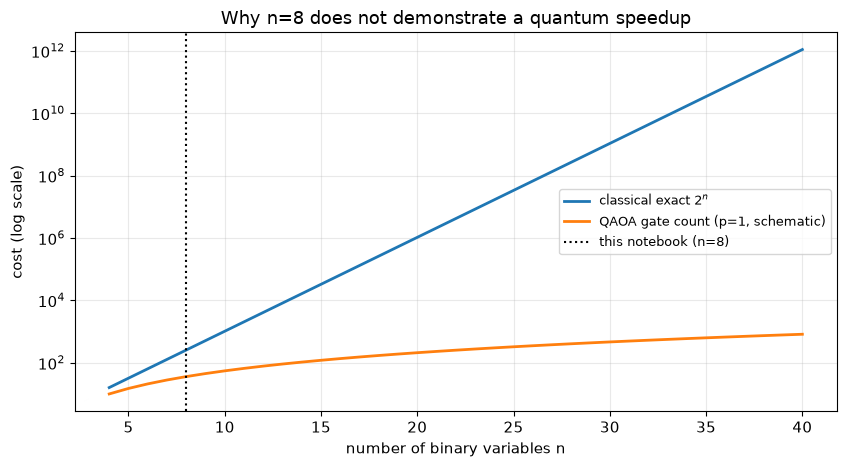

Take the figure as a cartoon of *search-space growth*, not as a wall-clock prediction.
This instance: exact QUBO 5.2 ms vs QAOA 2.48 s (statevector + 4 COBYLA restarts). Classical is faster, as expected.


In [11]:
ns = np.arange(4, 41)
brute = 2.0 ** ns
# very rough: p layers, O(n^2) ZZ terms, statevector 2^n * poly, *or* hardware shots
p = QAOA_P
zz_terms = ns * (ns - 1) / 2
qaoa_gates = p * (zz_terms + ns)   # cost + mixer, schematic
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.semilogy(ns, brute, label=r"classical exact $2^n$", lw=2)
ax.semilogy(ns, qaoa_gates, label=fr"QAOA gate count (p={p}, schematic)", lw=2)
ax.axvline(n_assets, color="k", ls=":", label=f"this notebook (n={n_assets})")
ax.set_xlabel("number of binary variables n")
ax.set_ylabel("cost (log scale)")
ax.set_title("Why n=8 does not demonstrate a quantum speedup")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print("Take the figure as a cartoon of *search-space growth*, not as a wall-clock prediction.")
print(f"This instance: exact QUBO {t_exact*1e3:.1f} ms vs QAOA {t_qaoa:.2f} s "
      f"(statevector + {QAOA_RESTARTS} COBYLA restarts). Classical is faster, as expected.")


## 10. Takeaways

- **Monte Carlo** is a picture of the whole simplex: 25k random long-only books,
  an empirical frontier, and a dense €50k ticket (integer shares + leftover cash).
- **QAOA** is a picture of a *discrete* cousin of Markowitz: pick \(K=4\) names,
  equal weight, QUBO + Ising + variational circuit. On 8 qubits the ground state
  is checkable by brute force — that is a feature of the demo, not a bug.
- The **visible difference** in names and notionals is mostly the encoding
  (continuous vs cardinality-\(K\)). The **algorithmic** difference is how the
  search is organised (random weights vs amplitudes over bitstrings).
- On the **same** Hamming-$K$ space, random search of 70 subsets is already exhaustive;
  QAOA shots are a fancier sampler of a space a laptop enumerates in a millisecond.
- The **out-of-sample** €50k paths (70/30 split, frozen lots, no costs) are the
  finance check that plug-in Sharpe does not replace — and they still use in-sample
  *ideas* trained on the first window, not a walk-forward with transaction costs.
- No speedup is claimed. The honest sentence for a thesis: *NISQ QAOA reproduces
  a small QUBO that classical enumeration already owns; the research question is
  whether the same pipeline still works when \(n\) no longer fits in \(2^n\)*.

**Next step**

- Walk-forward with a rolling window and a turnover penalty in the QUBO; or
  multi-bit lots (2 bits / name \(\Rightarrow\) 16 qubits) so QAOA chooses *size*.
  Optional: the same 8-qubit QAOA on IBM hardware via `qiskit_secrets.local.py`.
